# Visualising Predictions of Credit Card Fraud Detection Mode

In this notebook, we explore the predictions made by our trained fraud detection model. The goal is to better understand how well the model differentiates between fraudulent and legitimate transactions using various visualisation techniques.

We will:
- Load the predicted results
- Analyse the distribution of predictions
- Visualise confusion matrix and performance metrics
- Inspect individual prediction probabilities

In [ ]:
#Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Load the predicted results
df = pd.read_csv('../Data/creditcard_with_predictions.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Actual,Predicted,Fraud_Probability
0,111761.0,-1.238665,1.782662,-2.954137,-2.359850,3.103234,2.637558,0.676215,1.082094,0.036470,...,-0.106098,0.737220,-0.042802,0.129690,0.708588,0.440876,0.75,0,0,0.0
1,142740.0,2.297161,-0.610620,-1.760349,-1.170051,0.104713,-0.567724,-0.303647,-0.355296,-0.666158,...,-0.080302,0.123403,0.363044,0.075443,-0.036742,-0.064356,10.00,0,0,0.0
2,82483.0,1.254575,-0.024253,-0.024430,0.200540,0.155754,0.422772,-0.278075,0.267486,0.161909,...,0.032957,-1.208372,0.203056,0.185820,-0.030923,-0.010630,1.98,0,0,0.0
3,163647.0,1.977547,-0.371049,-0.415267,0.160196,-0.578756,-0.357777,-0.612011,0.112354,1.221502,...,0.312475,-0.419563,-0.384599,-0.920784,0.049403,-0.042238,1.00,0,0,0.0
4,82428.0,-0.638643,-0.949133,1.385888,-2.738219,-1.049450,0.642685,0.122373,0.106728,-2.496821,...,0.222049,-1.056056,0.043916,-0.392912,0.047665,0.108069,209.00,0,0,0.0


## Confusion Matrix

The confusion matrix helps us visualise the performance of the classification model by showing the counts of:
- True Positives (correctly predicted fraud)
- True Negatives (correctly predicted legit)
- False Positives (incorrectly predicted fraud)
- False Negatives (missed fraud cases)


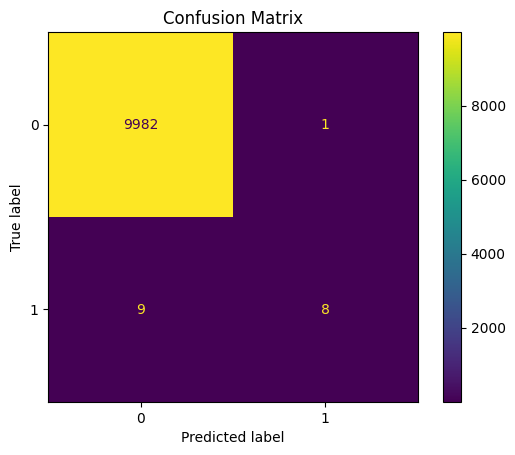

In [14]:
# Confusion matrix
cm = confusion_matrix(df['Actual'], df['Predicted'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()


## Histogram of Predicted Fraud Probabilities

This histogram shows the distribution of the predicted probabilities assigned by the model to each transaction for being fraudulent.

- Probabilities near 0 indicate high confidence that the transaction is legitimate.
- Probabilities near 1 indicate high confidence of fraud.
- Values in the middle reflect uncertainty.

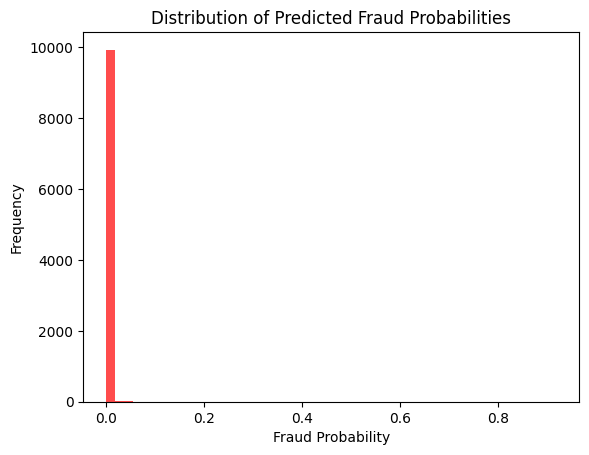

In [15]:
# Histogram of predicted probabilities
plt.hist(df['Fraud_Probability'], bins=50, color='red', alpha=0.7)
plt.title('Distribution of Predicted Fraud Probabilities')
plt.xlabel('Fraud Probability')
plt.ylabel('Frequency')
plt.show()

## Analyzing Predicted Frauds by Hour of Day

Here, we extract the hour of day from the transaction time (in seconds) and visualise how predicted fraudulent transactions are distributed across different hours.

This helps identify temporal patterns in predicted fraud activity.


In [ ]:
df['HourOfDay'] = (df['Time'] // 3600 % 24).astype(int)
fraud_by_hour = df[df['Predicted'] == 1].groupby('HourOfDay').size()

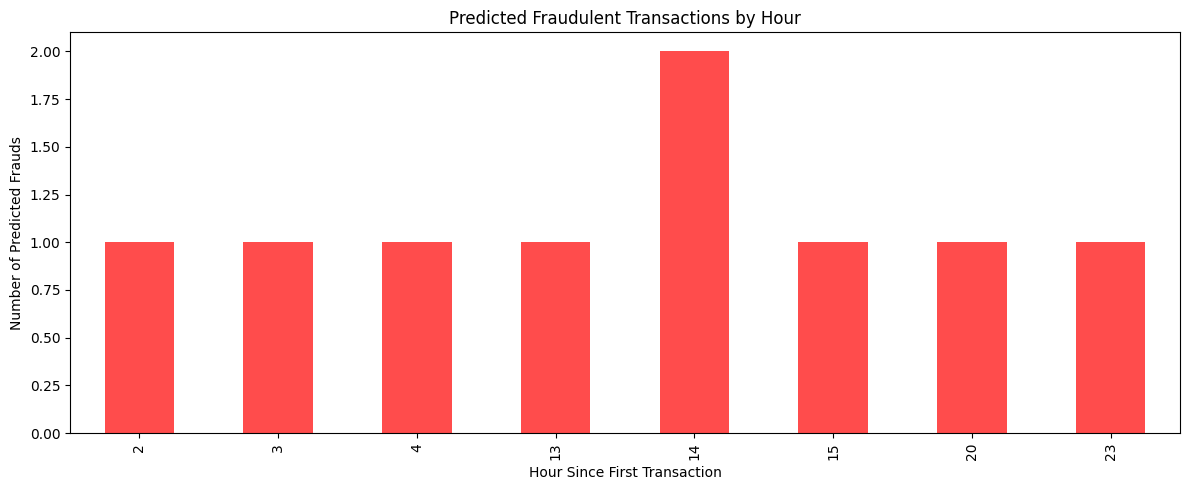

In [23]:
plt.figure(figsize=(12, 5))
fraud_by_hour.plot(kind='bar', color='red', alpha=0.7)
plt.title('Predicted Fraudulent Transactions by Hour')
plt.xlabel('Hour Since First Transaction')
plt.ylabel('Number of Predicted Frauds')
plt.tight_layout()
plt.show()


## Line Plot of Predicted Frauds by Hour

An alternative visualisation using a line plot to display the trend of predicted fraudulent transactions over the hours. 
This line plot shows the number of predicted fraudulent transactions for each hour of the day (from 0 to 23). 

Since the `HourOfDay` is extracted from the timestamp modulo 24 hours, this visualisation captures the **daily pattern** of fraud predictions highlighting which hours in a typical day have more predicted frauds.

Note that this is not a continuous time series over multiple days but a summary of fraud activity within a single 24-hour cycle.

This smooths out the hourly fraud counts and makes trends easier to spot.


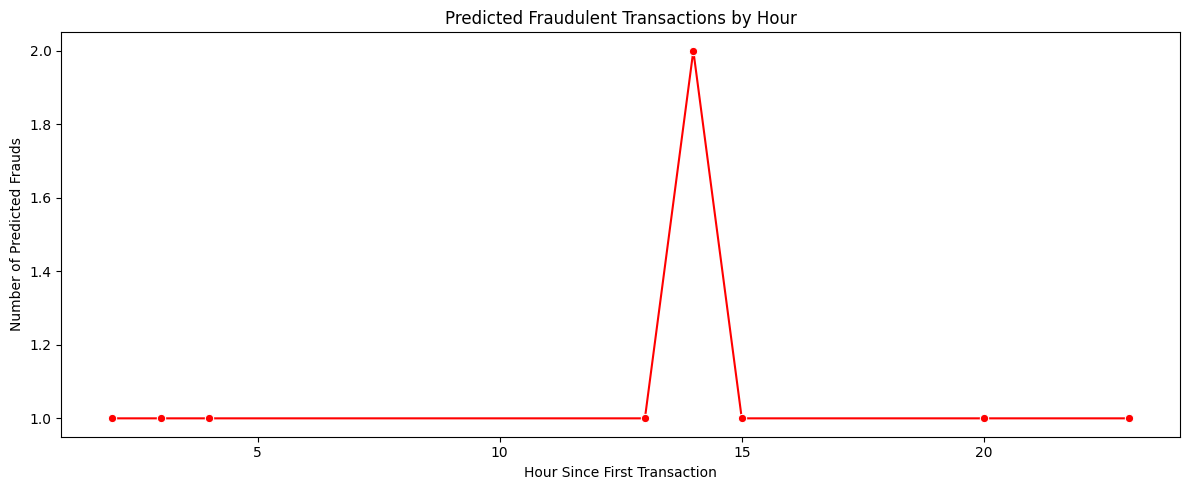

In [24]:
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.lineplot(x=fraud_by_hour.index, y=fraud_by_hour.values, marker='o', color='red')
plt.title('Predicted Fraudulent Transactions by Hour')
plt.xlabel('Hour Since First Transaction')
plt.ylabel('Number of Predicted Frauds')
plt.tight_layout()
plt.show()


## Conclusion

In this notebook, we explored the predictions made by our credit card fraud detection model through various visualisations.

- The confusion matrix highlighted the model’s classification performance, showing where it excels and where errors occur.
- The distribution of predicted fraud probabilities provided insight into the model’s confidence levels.
- From the line plot, we observe that the model predicts the highest number of fraudulent transactions around hour 14 (2 PM), indicating potential peak times for fraud activity during the day. This could help focus monitoring efforts during these hours.

It’s important to remember that these visualisations reflect the model’s predictions, which may differ from actual fraud events. Further analysis comparing predictions with true outcomes over time can help validate and improve the model.

Moving forward, these insights can guide us in refining the model, tuning thresholds, and preparing for deployment to effectively detect and prevent fraudulent transactions.
